In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Load dataset
df = pd.read_csv("healthcare_dataset.csv")

# Convert dates
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Create additional useful column
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

In [15]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive,14
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal,14
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal,30
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal,1
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal,24


In [16]:
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
434,William Stokes,81,Female,O+,Arthritis,2022-08-19,Craig Haley,Snyder-Park,Aetna,4377.601987,265,Elective,2022-09-09,Lipitor,Abnormal,21
435,Tiffany White,53,Female,AB-,Obesity,2020-11-09,Shelley Lang,"Griffin, Williamson and Burton",Cigna,33919.881462,153,Elective,2020-11-17,Paracetamol,Abnormal,8
436,Bradley Cross,79,Male,AB-,Obesity,2021-01-19,Kari Patrick,Cruz-Palmer,UnitedHealthcare,26017.318073,264,Urgent,2021-02-14,Lipitor,Inconclusive,26
437,Richard Brown,55,Male,AB-,Diabetes,2020-08-05,Jeremy Farley,Thomas-Anderson,Blue Cross,24371.732447,234,Emergency,2020-08-13,Paracetamol,Normal,8
438,Megan Gibson DVM,79,Female,B+,Obesity,2022-04-02,Brittany Keith,"Davis, Barrett and Mitchell",Blue Cross,12723.420483,174,Elective,2022-04-09,Paracetamol,Inconclusive,7


In [17]:
#Identify Data Types
print("Categorical Columns:")
print(df.select_dtypes(include=['object']).columns)

print("Continuous Columns:")
print(df.select_dtypes(include=['int64','float64']).columns)


Categorical Columns:
Index(['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Admission Type', 'Medication',
       'Test Results'],
      dtype='str')
Continuous Columns:
Index(['Age', 'Billing Amount', 'Room Number', 'Length of Stay'], dtype='str')


C:\Users\SAIRAM\AppData\Local\Temp\ipykernel_10752\136427311.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).columns)


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                439 non-null    str           
 1   Age                 439 non-null    int64         
 2   Gender              439 non-null    str           
 3   Blood Type          439 non-null    str           
 4   Medical Condition   439 non-null    str           
 5   Date of Admission   439 non-null    datetime64[us]
 6   Doctor              439 non-null    str           
 7   Hospital            439 non-null    str           
 8   Insurance Provider  439 non-null    str           
 9   Billing Amount      439 non-null    float64       
 10  Room Number         439 non-null    int64         
 11  Admission Type      439 non-null    str           
 12  Discharge Date      439 non-null    datetime64[us]
 13  Medication          439 non-null    str           
 14  Test 

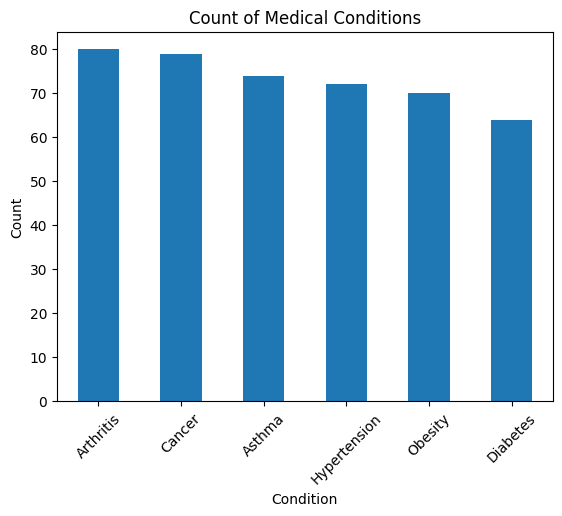

In [18]:
plt.figure()
df['Medical Condition'].value_counts().plot(kind='bar')
plt.title("Count of Medical Conditions")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

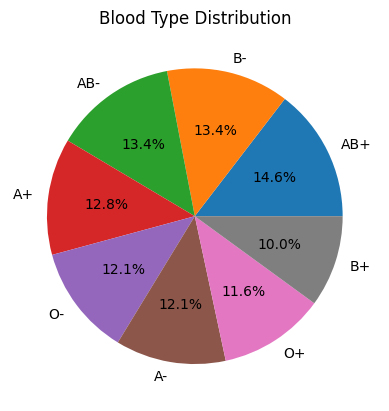

In [40]:
plt.figure()
df['Blood Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Blood Type Distribution")
plt.ylabel('')
plt.show()

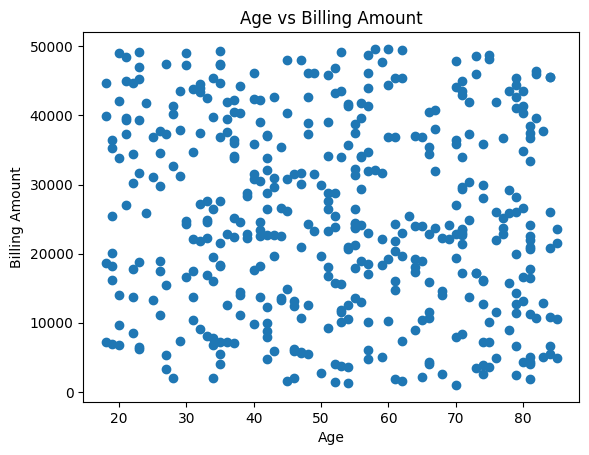

In [20]:
plt.figure()
plt.scatter(df['Age'], df['Billing Amount'])
plt.title("Age vs Billing Amount")
plt.xlabel("Age")
plt.ylabel("Billing Amount")
plt.show()

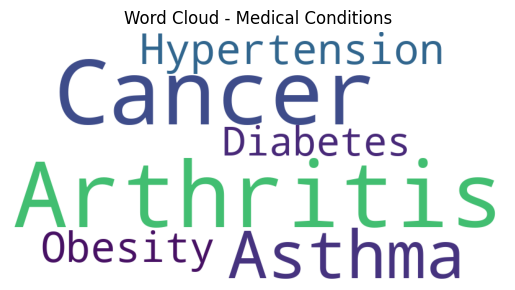

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all medical conditions into one text
text = " ".join(df['Medical Condition'].astype(str))

# Generate word cloud
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

# Show
plt.figure()
plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud - Medical Conditions")
plt.show()

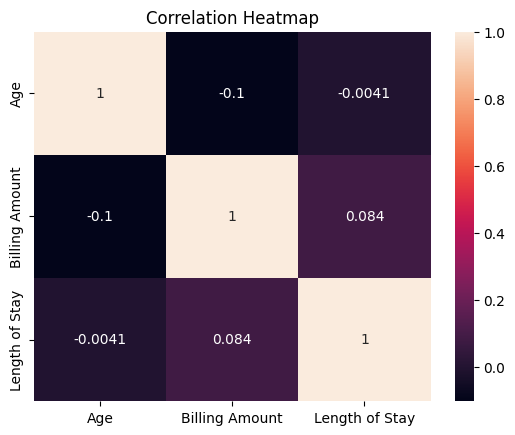

In [23]:
plt.figure()
sns.heatmap(df[['Age', 'Billing Amount', 'Length of Stay']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

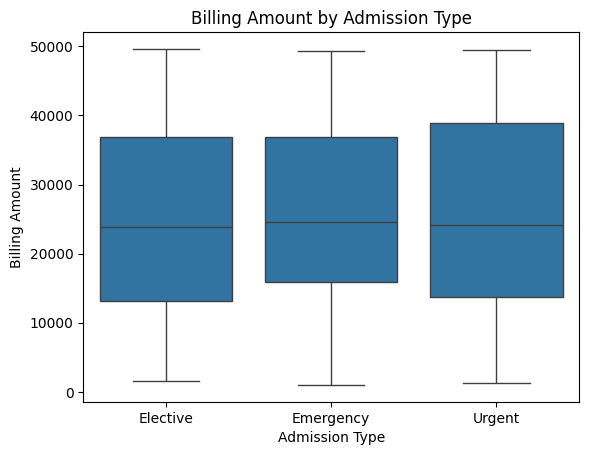

In [24]:
plt.figure()
sns.boxplot(x='Admission Type', y='Billing Amount', data=df)
plt.title("Billing Amount by Admission Type")
plt.show()